# Week 05 Weekly Challenge

**날짜:** 2026-06-08  
**주제:** 이미지 전이 학습, 모델 비교, 하이퍼파라미터 탐색, 자기회귀 챗봇

## Goal

1. CIFAR-10 또는 클래스별 폴더 이미지로 ResNet18을 학습한다.
2. 사전 훈련된 VGG16으로 전이 학습한다.
3. 같은 데이터 분할에서 두 모델의 정확도와 실행 시간을 비교한다.
4. 가상 분류 데이터에서 GridSearch와 RandomSearch를 비교한다.
5. LSTM 다음 단어 모델을 자기회귀 방식으로 사용하고 FastAPI로 제공한다.

## Setup

전체 모델 구현은 같은 폴더의 Python 모듈에 분리되어 있다. 노트북은 설정, 실행, 결과 확인 순서를 제공한다.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'image_model_comparison.py').exists():
    ROOT = Path('weeks/week-05/weekly-challenge').resolve()
sys.path.insert(0, str(ROOT))
print('작업 폴더:', ROOT)

작업 폴더: /Users/samrobert/Documents/GitHub/KakaoBootCamp/weeks/week-05/weekly-challenge


## Steps

### 1. ResNet18과 VGG16 전이 학습

기본값은 실제 CIFAR-10과 ImageNet 사전 학습 가중치다. `RUN_IMAGE_EXPERIMENT=True`로 바꾸면 두 모델을 같은 데이터 분할에서 학습한다.

In [2]:
RUN_IMAGE_EXPERIMENT = False
IMAGE_DATASET = 'cifar10'
IMAGE_EPOCHS = 3

if RUN_IMAGE_EXPERIMENT:
    command = [
        sys.executable, str(ROOT / 'image_model_comparison.py'),
        '--dataset', IMAGE_DATASET, '--models', 'both',
        '--epochs', str(IMAGE_EPOCHS), '--output-dir',
        str(ROOT / 'artifacts' / 'image_models'),
    ]
    subprocess.run(command, check=True, cwd=ROOT)
else:
    print('전체 이미지 학습은 비활성화되어 있습니다. RUN_IMAGE_EXPERIMENT=True로 실행하세요.')

전체 이미지 학습은 비활성화되어 있습니다. RUN_IMAGE_EXPERIMENT=True로 실행하세요.


### 2. 이미지 모델 결과 확인

정확도는 전체 정답 중 맞힌 비율이다. 혼동행렬의 행은 실제 클래스이고 열은 모델 예측 클래스다.

In [3]:
image_result_path = ROOT / 'artifacts' / 'image_models' / 'comparison_results.json'
image_chart_path = ROOT / 'artifacts' / 'image_models' / 'model_comparison.png'
if image_result_path.exists():
    image_results = json.loads(image_result_path.read_text(encoding='utf-8'))
    for result in image_results['results']:
        print(f"{result['model']}: test accuracy={result['test_accuracy']:.1%}, "
              f"time={result['elapsed_seconds']:.1f}s")
    display(Image(filename=str(image_chart_path)))
else:
    print('아직 전체 CIFAR-10 비교 결과가 없습니다. 이전 셀에서 실험을 실행하세요.')

아직 전체 CIFAR-10 비교 결과가 없습니다. 이전 셀에서 실험을 실행하세요.


### 3. GridSearch와 RandomSearch

두 방법 모두 같은 가상 데이터, RandomForest, 교차검증 분할을 사용한다. GridSearch는 후보 조합 전체를 확인하고 RandomSearch는 지정된 횟수만큼 조합을 추출한다.

In [4]:
RUN_HYPERPARAMETER_SEARCH = False
search_output = ROOT / 'artifacts' / 'hyperparameter_search'
if RUN_HYPERPARAMETER_SEARCH:
    subprocess.run([
        sys.executable, str(ROOT / 'hyperparameter_search.py'),
        '--output-dir', str(search_output),
    ], check=True, cwd=ROOT)
else:
    print('저장된 탐색 결과를 사용합니다.')

저장된 탐색 결과를 사용합니다.


GridSearch: test accuracy=94.6%, time=12.8s, candidates=24
RandomSearch: test accuracy=94.6%, time=4.1s, candidates=6


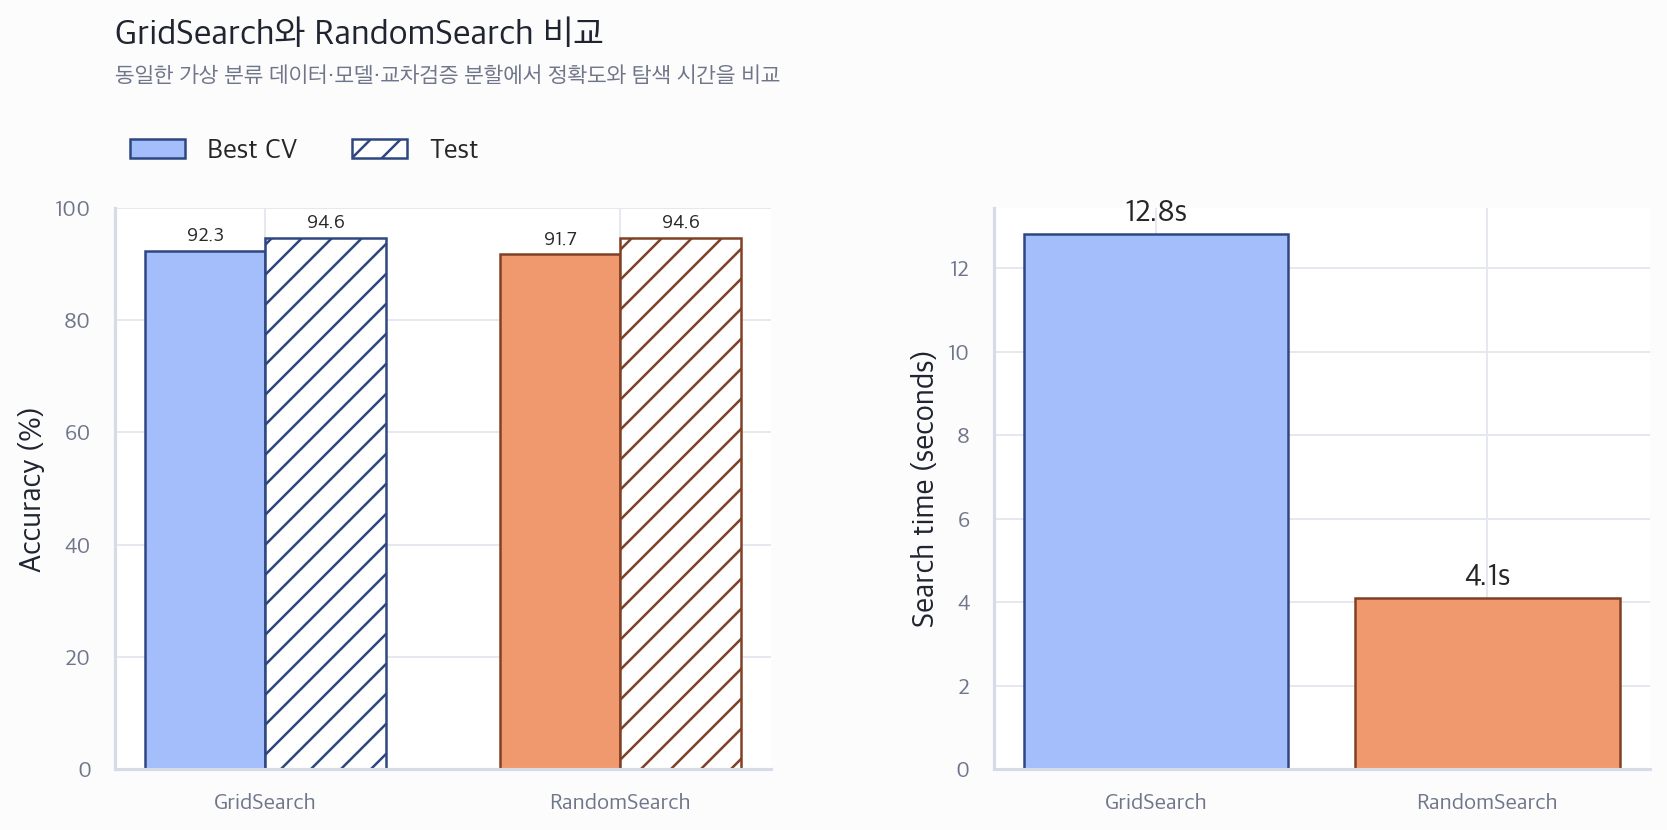

In [5]:
search_summary_path = search_output / 'search_summary.json'
if search_summary_path.exists():
    search_summary = json.loads(search_summary_path.read_text(encoding='utf-8'))
    for result in search_summary['results']:
        print(f"{result['search']}: test accuracy={result['test_accuracy']:.1%}, "
              f"time={result['elapsed_seconds']:.1f}s, "
              f"candidates={result['evaluated_candidates']}")
    display(Image(filename=str(search_output / 'search_comparison.png')))
else:
    print('탐색 결과가 없습니다. RUN_HYPERPARAMETER_SEARCH=True로 실행하세요.')

### 4. 다음 단어 예측과 자기회귀 문장 생성

모델은 현재 문맥으로 다음 단어 하나를 예측한다. 선택된 단어를 다시 문맥 뒤에 붙여 같은 과정을 반복하면 문장이 생성된다.

In [6]:
from chatbot.model import generate_text, load_checkpoint, predict_next_words

chatbot_path = ROOT / 'artifacts' / 'chatbot.pt'
if not chatbot_path.exists():
    subprocess.run([sys.executable, '-m', 'chatbot.train'], check=True, cwd=ROOT)

model, vocabulary, config, metadata = load_checkpoint(chatbot_path)
next_words = predict_next_words(model, vocabulary, config, '오늘 오전', top_k=5)
print('다음 단어 후보:', [(word, f'{probability:.1%}') for word, probability in next_words])

for prompt in ['오늘 오전', '오늘 저녁에는', '머신러닝 모델은', 'GridSearch는']:
    generated = generate_text(
        model, vocabulary, config, prompt,
        max_new_tokens=20, temperature=0.7, top_k=5,
    )
    print(f'{prompt} -> {generated}')

다음 단어 후보: [('일정은', '38.1%'), ('회의가', '35.3%'), ('공부를', '25.1%'), ('데이터', '0.1%'), ('저녁에는', '0.0%')]
오늘 오전 -> 오늘 오전 회의가 있어서 커피를 마셨어요.
오늘 저녁에는 -> 오늘 저녁에는 친구와 영화를 볼 예정입니다.
머신러닝 모델은 -> 머신러닝 모델은 학습 데이터의 패턴을 찾아 예측합니다.
GridSearch는 -> GridSearch는 정해진 후보 조합을 모두 확인합니다.


### 5. FastAPI 실행

터미널에서 아래 명령을 실행한 뒤 `http://127.0.0.1:8000`에 접속한다.

```bash
cd weeks/week-05/weekly-challenge
python3 -m uvicorn chatbot.app:app --reload --port 8000
```

API 문서는 `http://127.0.0.1:8000/docs`에서 확인할 수 있다.

## Checks

In [7]:
checks = {
    'ResNet/VGG16 비교 코드': (ROOT / 'image_model_comparison.py').exists(),
    'GridSearch/RandomSearch 결과': search_summary_path.exists(),
    '챗봇 학습 모델': chatbot_path.exists(),
    'FastAPI 앱': (ROOT / 'chatbot' / 'app.py').exists(),
}
for name, passed in checks.items():
    print(f"[{'PASS' if passed else 'TODO'}] {name}")

[PASS] ResNet/VGG16 비교 코드
[PASS] GridSearch/RandomSearch 결과
[PASS] 챗봇 학습 모델
[PASS] FastAPI 앱


## Next Steps

- CIFAR-10 전체 비교를 실행해 두 모델의 실제 테스트 정확도를 기록한다.
- 개인 이미지 데이터가 있다면 `--dataset imagefolder --image-dir 경로`로 바꾼다.
- 챗봇 생성 품질을 높이려면 `chatbot/corpus.txt`의 문장 수와 표현 범위를 늘린다.
- 정확도뿐 아니라 실행 시간과 혼동행렬의 오류 유형을 함께 보고 모델을 선택한다.